# Christmas Gift Price Prediction — Project Overview

##  Context
Online retailers use promotions and special offers to attract new visitors, increase traffic, and boost sales. Understanding product characteristics and customer behavior helps improve these strategies.
This project begins with **unsupervised learning** to explore the structure of the data before predicting prices.

##  Dataset Description
The dataset contains different types of information related to gifts:

- **gift_id** — Unique identifier
- **gift_type** — Type of gift (ex: clothes, perfumes…)
- **gift_category** — Category within the gift type
- **gift_cluster** — Industry or group the gift belongs to
- **instock_date** — Date when the product arrived in stock
- **stock_update_date** — Last stock update date
- **lsg_1 to lsg_6** — Anonymized numerical features
- **uk_date1, uk_date2** — Buyer-related dates
- **is_discounted_**


# Phase 1 : UNSUPERVISED LEARNING


In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scipy


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Partie A — Data Exploration
In this first step, we will explore our dataset before any preprocessing or clustering

In [2]:
# import librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



#### Step 1 — Loading the dataset
We load the CSV file and display the first lines to check its structure.

In [3]:
df = pd.read_csv("train..csv")
df.head()

,gift_id,gift_type,gift_category,gift_cluster,instock_date,stock_update_date,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,uk_date1,uk_date2,is_discounted,volumes,price
0,GF_11156,61,534,3942,2014-02-21 05:07:06.000,2016-11-09 15:49:51.000,3377,5221,504,1912,10,554,2014-02-24 08:07:06.000,2014-02-24 07:07:06.000,0,NaN,175.54
1,GF_11157,61,534,3942,2014-02-21 06:07:06.000,2016-11-11 13:49:51.000,3377,5221,504,1912,10,554,2014-02-22 07:07:06.000,2014-02-24 06:07:06.000,1,NaN,95.80
2,GF_15689,584,262,0,2014-02-21 09:30:21.000,2016-03-24 14:46:18.000,5290,1579,3203,1912,9,1578,2016-01-26 00:04:45.000,2016-03-18 02:00:00.000,1,NaN,107.35
3,GF_11155,61,534,3942,2014-02-22 05:07:06.000,2016-11-10 16:49:51.000,3377,5221,504,1912,10,554,2016-11-07 13:49:51.000,2016-11-06 04:00:00.000,0,NaN,172.90
4,GF_11158,61,534,3942,2014-02-22 07:07:06.000,2016-11-10 13:49:51.000,3377,5221,504,1912,9,554,2016-11-07 15:49:51.000,2016-11-06 01:00:00.000,1,NaN,77.72


#### Step 2 - General information
We display the types of columns and the structure of the dataset.

In [4]:
print(" Dataset information:")
df.info()
df.describe()

 Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20279 entries, 0 to 20278
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gift_id            20279 non-null  object 
 1   gift_type          20279 non-null  int64  
 2   gift_category      20279 non-null  int64  
 3   gift_cluster       20279 non-null  int64  
 4   instock_date       20279 non-null  object 
 5   stock_update_date  20279 non-null  object 
 6   lsg_1              20279 non-null  int64  
 7   lsg_2              20279 non-null  int64  
 8   lsg_3              20279 non-null  int64  
 9   lsg_4              20279 non-null  int64  
 10  lsg_5              20279 non-null  int64  
 11  lsg_6              20279 non-null  int64  
 12  uk_date1           20279 non-null  object 
 13  uk_date2           20279 non-null  object 
 14  is_discounted      20279 non-null  int64  
 15  volumes            7323 non-null   float64
 16  

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,price
count,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,7323.000000,20279.000000
mean,739.554662,394.171557,3303.358548,5314.595345,4187.653928,4866.945510,1679.152226,8.652695,1265.898171,0.229646,15.515363,143.404411
std,389.216989,235.077769,2541.082549,2703.317282,2274.875522,2713.856392,485.699119,2.349388,697.838495,0.420616,7.579669,267.281159
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,5.000000,0.010000
25%,403.000000,188.000000,587.000000,3311.000000,2251.000000,2548.000000,1801.000000,9.000000,577.500000,0.000000,9.000000,45.645000
50%,825.000000,433.000000,3231.000000,5520.000000,4246.000000,4839.000000,1912.000000,9.000000,1616.000000,0.000000,13.000000,75.600000
75%,1032.000000,534.000000,5787.000000,7535.000000,6504.500000,7387.000000,1912.000000,10.000000,1899.000000,0.000000,24.000000,126.845000
max,1360.000000,893.000000,7567.000000,9979.000000,7604.000000,9493.000000,2056.000000,10.000000,2065.000000,1.000000,29.000000,7010.270000


#### Step 3 - Missing value

In [5]:
df.isnull().sum()

gift_id                  0
gift_type                0
gift_category            0
gift_cluster             0
instock_date             0
stock_update_date        0
lsg_1                    0
lsg_2                    0
lsg_3                    0
lsg_4                    0
lsg_5                    0
lsg_6                    0
uk_date1                 0
uk_date2                 0
is_discounted            0
volumes              12956
price                    0
dtype: int64

here we realize that the volume lacks a lot of values, it can be related to the fact that the products are not yet sold for example. Knowing that volume is important information for us, we will do the median (because we cannot delete lines without volumes or replace them with 0)

In [6]:
df["volumes"] = df["volumes"].fillna(df["volumes"].median())


#### Step 4 - Number of rows and columns
Small overview of the dataset size.



In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20279
Number of columns: 17


#### Step 5 - List of columns
To quickly identify important variables.

In [8]:

print("Dataset columns:")
df.columns

Dataset columns:


Index(['gift_id', 'gift_type', 'gift_category', 'gift_cluster', 'instock_date',
       'stock_update_date', 'lsg_1', 'lsg_2', 'lsg_3', 'lsg_4', 'lsg_5',
       'lsg_6', 'uk_date1', 'uk_date2', 'is_discounted', 'volumes', 'price'],
      dtype='object')

#### Step 6 - Descriptive statistics
Statistical summary of numerical and categorical variables.

In [9]:
df.describe(include='all')

,gift_id,gift_type,gift_category,gift_cluster,instock_date,stock_update_date,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,uk_date1,uk_date2,is_discounted,volumes,price
count,20279,20279.000000,20279.000000,20279.000000,20279,20279,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279,20279,20279.000000,20279.000000,20279.000000
unique,20279,NaN,NaN,NaN,17147,14794,NaN,NaN,NaN,NaN,NaN,NaN,16384,7210,NaN,NaN,NaN
top,GF_11156,NaN,NaN,NaN,2015-09-22 14:30:05.000,2017-03-12 18:39:44.000,NaN,NaN,NaN,NaN,NaN,NaN,2017-03-31 12:40:24.000,2016-11-04 02:00:00.000,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,7,17,NaN,NaN,NaN,NaN,NaN,NaN,17,97,NaN,NaN,NaN
mean,NaN,739.554662,394.171557,3303.358548,NaN,NaN,5314.595345,4187.653928,4866.945510,1679.152226,8.652695,1265.898171,NaN,NaN,0.229646,13.908329,143.404411
std,NaN,389.216989,235.077769,2541.082549,NaN,NaN,2703.317282,2274.875522,2713.856392,485.699119,2.349388,697.838495,NaN,NaN,0.420616,4.712153,267.281159
min,NaN,1.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,NaN,NaN,0.000000,5.000000,0.010000
25%,NaN,403.000000,188.000000,587.000000,NaN,NaN,3311.000000,2251.000000,2548.000000,1801.000000,9.000000,577.500000,NaN,NaN,0.000000,13.000000,45.645000
50%,NaN,825.000000,433.000000,3231.000000,NaN,NaN,5520.000000,4246.000000,4839.000000,1912.000000,9.000000,1616.000000,NaN,NaN,0.000000,13.000000,75.600000
75%,NaN,1032.000000,534.000000,5787.000000,NaN,NaN,7535.000000,6504.500000,7387.000000,1912.000000,10.000000,1899.000000,NaN,NaN,0.000000,13.000000,126.845000


##### Conclusion after describe:
The dataset contains:
* Many digital features (lsg_1 lsg_6)
* Several dates to transform
* An unnecessary ID column
* An unbalanced binary column (is_discounted)
* A very skewed price column (outliers)

2. Two mandatory actions:
* Fill in the missing values of volumes (did it in the section missing value in top)
* Remove or reduce outliers in price

#### Step 7 - Delete unnecessary columns
gift_id is a unique identifier it is not used for the ML

In [10]:
df = df.drop(["gift_id"], axis=1)


In [11]:
df.columns

Index(['gift_type', 'gift_category', 'gift_cluster', 'instock_date',
       'stock_update_date', 'lsg_1', 'lsg_2', 'lsg_3', 'lsg_4', 'lsg_5',
       'lsg_6', 'uk_date1', 'uk_date2', 'is_discounted', 'volumes', 'price'],
      dtype='object')

#### Step 8 - Check for duplicates

In [12]:
duplicates = df.duplicated().sum()
print("Number of duplicates :", duplicates)

df = df.drop_duplicates()


Number of duplicates : 0


#### Step 9 - Convert non-numeric columns

In [13]:
#Convert dates to datetime
df["instock_date"] = pd.to_datetime(df["instock_date"])
df["stock_update_date"] = pd.to_datetime(df["stock_update_date"])
df["uk_date1"] = pd.to_datetime(df["uk_date1"])
df["uk_date2"] = pd.to_datetime(df["uk_date2"])


In [14]:
#Extract useful information --> create groups
df["instock_year"] = df["instock_date"].dt.year
df["stock_update_year"] = df["stock_update_date"].dt.year
df["uk_year1"] = df["uk_date1"].dt.year
df["uk_year2"] = df["uk_date2"].dt.year


In [15]:
#Delete the original date columns
df = df.drop(["instock_date", "stock_update_date", "uk_date1", "uk_date2"], axis=1)


#### Step 10 - Detection and processing of OUTLIERS



In [16]:
# outliers PRICE
df["price"].describe()


count    20279.000000
mean       143.404411
std        267.281159
min          0.010000
25%         45.645000
50%         75.600000
75%        126.845000
max       7010.270000
Name: price, dtype: float64

analyze: The vast majority of prices are between €45 and 130€ --> It’s totally normal for small gifts.
The max = €7010 is extremely abnormal
--> More than 50x greater than the 75th percentile

==> we will have to filter the outliers but not too much so as not to lose too much data

In [17]:
df = df[df["price"] <= 600]


In [18]:
# Outlier VOLUMES
df["volumes"].describe()

count    19363.000000
mean        13.952228
std          4.817316
min          5.000000
25%         13.000000
50%         13.000000
75%         13.000000
max         29.000000
Name: volumes, dtype: float64

min 5 and max 29 : low amplitude = No need to filter.

In [19]:
# Outliers LSG_number
df["lsg_3"].describe() # choose 3 for just look variable

count    19363.000000
mean      4888.849094
std       2723.006757
min          0.000000
25%       2567.000000
50%       4817.000000
75%       7460.000000
max       9493.000000
Name: lsg_3, dtype: float64

analyze : we had no need for a filter but the values are consistent with each other.
The min = 0 is possible depending on the direction of the variable.
The max = 9493 is consistent with the distribution (75% = 7460).
So you have no reason to apply an outliers filter here

#### Step 11 : Correlation between colummns

In [20]:
numeric_df = df.select_dtypes(include=['number'])
correlation = numeric_df.corr()
print(correlation)

                   gift_type  gift_category  gift_cluster     lsg_1     lsg_2  \
gift_type           1.000000       0.037984     -0.093766  0.360172 -0.043284   
gift_category       0.037984       1.000000     -0.055620 -0.046830  0.043278   
gift_cluster       -0.093766      -0.055620      1.000000 -0.079583  0.062323   
lsg_1               0.360172      -0.046830     -0.079583  1.000000 -0.144857   
lsg_2              -0.043284       0.043278      0.062323 -0.144857  1.000000   
lsg_3               0.550155      -0.078098      0.061058  0.525301 -0.043184   
lsg_4               0.107123       0.167558     -0.008025 -0.099819 -0.032478   
lsg_5               0.017698      -0.199527     -0.023732 -0.069527 -0.093525   
lsg_6               0.075116       0.116042      0.013224 -0.024027 -0.048852   
is_discounted      -0.014145       0.051788      0.034646 -0.185355  0.015691   
volumes             0.013581      -0.012737      0.056101  0.165298  0.052152   
price               0.095092

###### Analyse of tab correlation
* The variables lsg_1 to lsg_6 are strongly correlated with each other, indicating strong redundancy. They probably measure similar aspects of the same process.

* The variable price shows little correlation with the other variables: its evolution does not linearly depend on the numerical columns present.

* The variable volumes has only weak to moderate correlations, which suggests that no variable clearly explains it alone.

* No negative or incoherent correlation appears, which confirms the overall consistency of the dataset.

## Partie B


What has already been done (in part A)
* Missing value treatment -> we have processed the missing values of volumes with the median
* Duplicate removal -> have detected and deleted duplicates
* Outlier handling -> have filtered the price outliers and checked the other columns

What remains to be done to complete part B
* Encoding of categorical columns
* Feature Scaling

In [21]:
df

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,price,instock_year,stock_update_year,uk_year1,uk_year2
0,61,534,3942,3377,5221,504,1912,10,554,0,13.0,175.54,2014,2016,2014,2014
1,61,534,3942,3377,5221,504,1912,10,554,1,13.0,95.80,2014,2016,2014,2014
2,584,262,0,5290,1579,3203,1912,9,1578,1,13.0,107.35,2014,2016,2016,2016
3,61,534,3942,3377,5221,504,1912,10,554,0,13.0,172.90,2014,2016,2016,2016
4,61,534,3942,3377,5221,504,1912,9,554,1,13.0,77.72,2014,2016,2016,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20274,105,704,6448,2055,6883,995,1912,10,1899,0,13.0,57.68,2016,2016,2016,2016
20275,1220,526,817,8323,6753,6706,1912,10,1899,0,13.0,122.87,2016,2016,2016,2016
20276,509,705,821,2826,4009,2912,1912,10,1451,0,13.0,47.14,2016,2017,2017,2017
20277,682,213,5620,2089,6883,3607,1912,10,822,0,13.0,47.68,2016,2016,2016,2016


-> we see that there are only numerical values = no need for encoding

We need to normalize the numerical values = Feature scaling
* Machine learning models and clustering algorithms require variables to be on similar scales. Here, we apply StandardScaler to all numerical features except the target (price)
* WHY except price ? In a price prediction project, price is the value that your model must learn to predict. One must NEVER transform the target variable into the same DataFrame

In [22]:
import pandas as pd
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib   #sauvegarde le scaler
df_scaled = df.copy()

In [24]:
# List the columns to be standardized / normalized
features_to_scale = [
    'gift_type','gift_category','gift_cluster',
    'lsg_1','lsg_2','lsg_3','lsg_4','lsg_5','lsg_6',
    'is_discounted','volumes',
    'instock_year','stock_update_year','uk_year1','uk_year2'
]
print("Number of columns to scale :", len(features_to_scale))
print("Columns :", features_to_scale)

Number of columns to scale : 15
Columns : ['gift_type', 'gift_category', 'gift_cluster', 'lsg_1', 'lsg_2', 'lsg_3', 'lsg_4', 'lsg_5', 'lsg_6', 'is_discounted', 'volumes', 'instock_year', 'stock_update_year', 'uk_year1', 'uk_year2']


We gonna take : StandardScaler (mean = 0, standard deviation = 1)

In [25]:
# StandardScaler: apply centered-reduced scaling
scaler_std = StandardScaler()

# Fit on the data (learns the mean and standard deviation) then transform
df_scaled[features_to_scale] = scaler_std.fit_transform(df_scaled[features_to_scale])

# Save the scaler for reuse (ex: during prediction on new data)
joblib.dump(scaler_std, "scaler_standard.joblib")

# Show start of dataframe
df_scaled.head()

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,price,instock_year,stock_update_year,uk_year1,uk_year2
0,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,-0.562021,-0.197673,175.54,-3.575022,-0.807984,-3.355731,-3.470222
1,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,1.779291,-0.197673,95.80,-3.575022,-0.807984,-3.355731,-3.470222
2,-0.369305,-0.515691,-1.383019,0.014895,-1.182388,-0.619129,0.445598,0.027951,0.436250,1.779291,-0.197673,107.35,-3.575022,-0.807984,-0.278731,-0.303909
3,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,-0.562021,-0.197673,172.90,-3.575022,-0.807984,-0.278731,-0.303909
4,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.027951,-1.024675,1.779291,-0.197673,77.72,-3.575022,-0.807984,-0.278731,-0.303909


In [26]:
# quick check
print(df_scaled[features_to_scale].mean().round(4))
print(df_scaled[features_to_scale].std().round(4))


gift_type           -0.0
gift_category        0.0
gift_cluster         0.0
lsg_1               -0.0
lsg_2               -0.0
lsg_3                0.0
lsg_4               -0.0
lsg_5                0.0
lsg_6                0.0
is_discounted       -0.0
volumes             -0.0
instock_year        -0.0
stock_update_year   -0.0
uk_year1             0.0
uk_year2             0.0
dtype: float64
gift_type            1.0
gift_category        1.0
gift_cluster         1.0
lsg_1                1.0
lsg_2                1.0
lsg_3                1.0
lsg_4                1.0
lsg_5                1.0
lsg_6                1.0
is_discounted        1.0
volumes              1.0
instock_year         1.0
stock_update_year    1.0
uk_year1             1.0
uk_year2             1.0
dtype: float64


=> Standardization worked correctly: all the numerical variables ri have a mean close to 0 and a standard deviation close to 1.

In [27]:
df_scaled.isna().sum()


gift_type            0
gift_category        0
gift_cluster         0
lsg_1                0
lsg_2                0
lsg_3                0
lsg_4                0
lsg_5                0
lsg_6                0
is_discounted        0
volumes              0
price                0
instock_year         0
stock_update_year    0
uk_year1             0
uk_year2             0
dtype: int64

In [28]:
df_scaled.duplicated().sum()

np.int64(5)

## Part C : Visualization


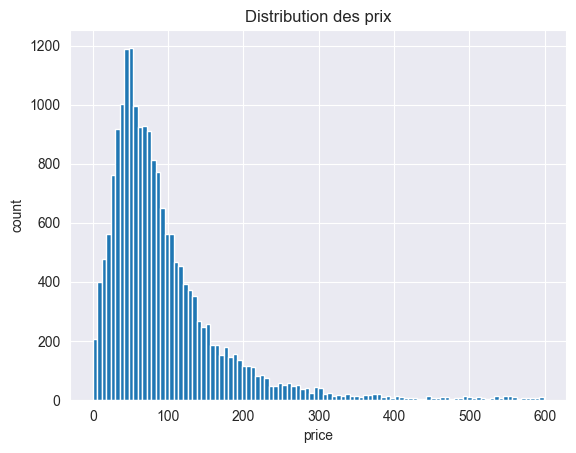

In [29]:
#Price histogram
plt.hist(df["price"], bins=100)
plt.title("Distribution des prix")
plt.xlabel("price")
plt.ylabel("count")
plt.show()


The price histogram clearly shows a bias towards the right: most gifts are low to medium priced, with only a few being very expensive. This suggests that a logarithmic transformation of the target price could help stabilise the variance for certain models.

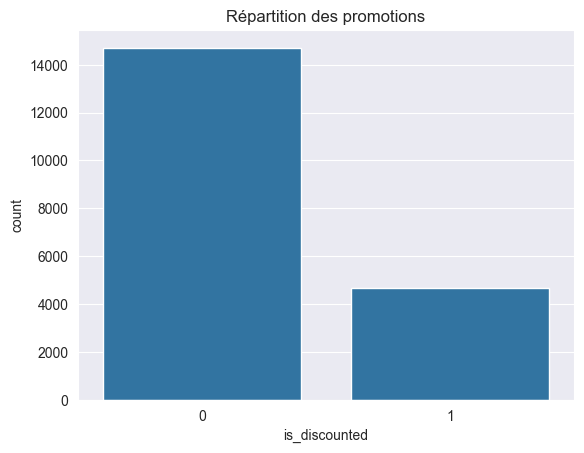

In [30]:
#CountPlot discout
sns.countplot(x="is_discounted", data=df)
plt.title("Répartition des promotions")
plt.show()


The promotional graph shows a significant imbalance: most products do not benefit from discounts, and promotional items generally have lower average prices. The ‘is_discounted’ feature is therefore informative, but insufficient on its own to explain the price.

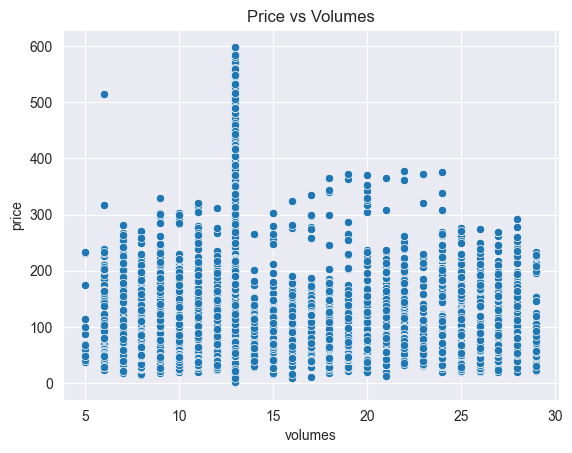

In [31]:
# Scatter pplot : price VS volume
sns.scatterplot(x="volumes", y="price", data=df)
plt.title("Price vs Volumes")
plt.show()

The scatter plot representing price versus volume shows no clear trend and virtually no correlation. This indicates that sales volume provides very little guidance for predicting price in this dataset

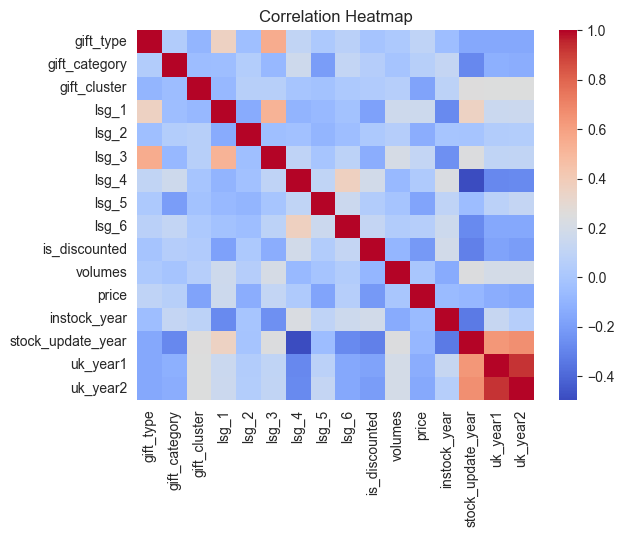

In [32]:
#HeatMap
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heat map reveals strong correlations between certain date-related variables, indicating redundancy (e.g. uk_year1 and uk_year2). Correlations with price are all modest, suggesting that the target depends on a combination of several weakly predictive characteristics rather than a single dominant variable.

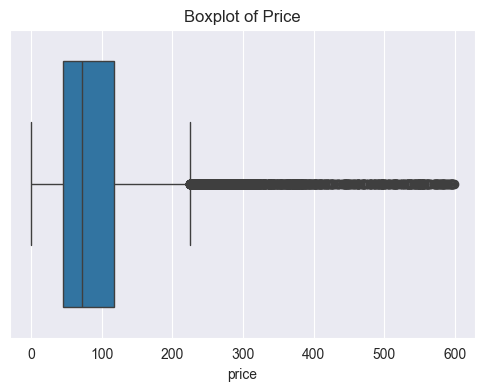

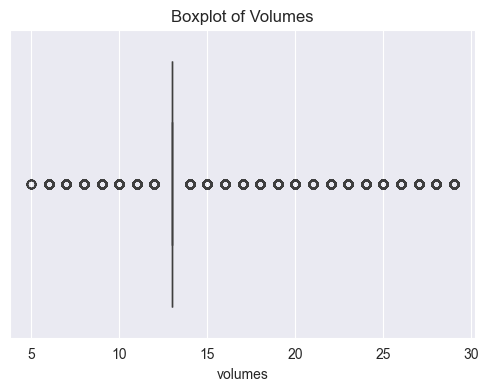

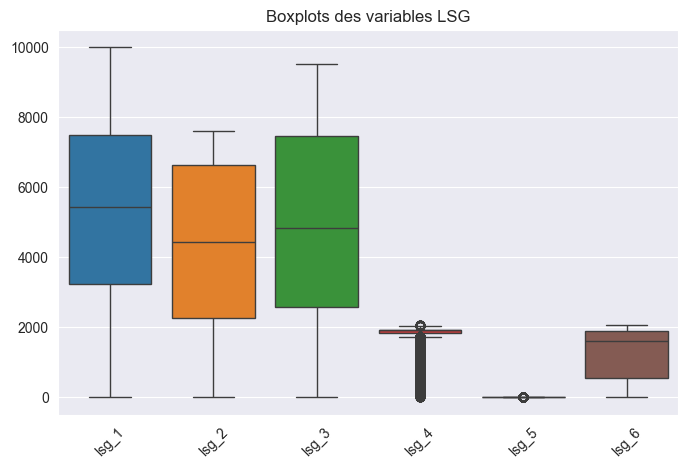

In [33]:
# Boxplot for Price
plt.figure(figsize=(6,4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()

# Boxplot for Volumes
plt.figure(figsize=(6,4))
sns.boxplot(x=df["volumes"])
plt.title("Boxplot of Volumes")
plt.show()

#  Boxplots des variables LSG
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["lsg_1","lsg_2","lsg_3","lsg_4","lsg_5","lsg_6"]])
plt.title("Boxplots des variables LSG")
plt.xticks(rotation=45)
plt.show()


## Conclusion part A B C


#### What has been completed
* 1. Missing Values
The missing values of volumes have been replaced by the median, avoiding the loss of important data.

* 2. Duplicate Removal
All duplicates were detected and then deleted, ensuring a more reliable dataset.

* 3. Outlier Handling
The extreme values of price (> 600€) were filtered because they were abnormal and not relevant.
The other numerical variables did not require outliers processing.

* 4. Datetime Conversion
The dates were converted into datetime and then transformed into annual variables (*_year).
The initial date columns have been removed.

* 5. Encoding
No encoding needed: all the remaining variables are numeric.

* 6. Feature Scaling
The explanatory variables have been standardized with StandardScaler
(mean = 0, standard deviation = 1).
The scaler has been saved (scaler_standard.joblib) for future use.
* 7. Visualisation
- Histograms for price to understand the distribution
- Scatter plots for price vs volumes to explore trends
- Bar plot for is_discounted to visualize promotions
- Correlation heatmap to detect relationships between numerical variables
- Boxplots (added for price, volumes, LSG variables) to detect outliers and check distribution
These visualizations provide a clear understanding of the dataset and highlight important patterns and redundancies.

## Part D :Apply Clustering (Mandatory)

In this section, we apply clustering algorithm :
* K-Means Clustering ->
This method will help us identify natural groups in the dataset based on the standardized numerical features.

In [34]:
# Prepare data for clustering: remove target column
X = df_scaled.drop(columns=["price"])
X.head()

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,instock_year,stock_update_year,uk_year1,uk_year2
0,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,-0.562021,-0.197673,-3.575022,-0.807984,-3.355731,-3.470222
1,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,1.779291,-0.197673,-3.575022,-0.807984,-3.355731,-3.470222
2,-0.369305,-0.515691,-1.383019,0.014895,-1.182388,-0.619129,0.445598,0.027951,0.436250,1.779291,-0.197673,-3.575022,-0.807984,-0.278731,-0.303909
3,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,-0.562021,-0.197673,-3.575022,-0.807984,-0.278731,-0.303909
4,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.027951,-1.024675,1.779291,-0.197673,-3.575022,-0.807984,-0.278731,-0.303909


In [35]:
from sklearn.cluster import KMeans

# Provisional choice of k
k_provisional = 4

kmeans = KMeans(n_clusters=k_provisional, random_state=42)
df_scaled["kmeans_cluster"] = kmeans.fit_predict(X)

df_scaled["kmeans_cluster"].value_counts()


kmeans_cluster
1    12119
0     2991
2     2274
3     1979
Name: count, dtype: int64

 Cluster Distribution Analysis

The provisional K-Means clustering with k = 4 produces an unbalanced cluster structure:

- Cluster 1 is very large (12,119 samples), gathering the majority of the dataset.
- The other clusters are significantly smaller (between 1,900 and 3,000 samples).

This suggests that the dataset may have a dominant group of similar products, while the remaining items form smaller, more specific groups.

The imbalance does not necessarily mean that k=4 is incorrect, but it indicates that we should verify this choice carefully in Part E (Elbow Method, Silhouette Score, Davies–Bouldin Index).


## Part E : Determine Optimal Number of Clusters

Now we verify whether the provisional choice (k = 4) was appropriate.
We use the following methods:

- Elbow Method
- Silhouette Score
- Davies–Bouldin Index
- Dendrogram (for hierarchical clustering)

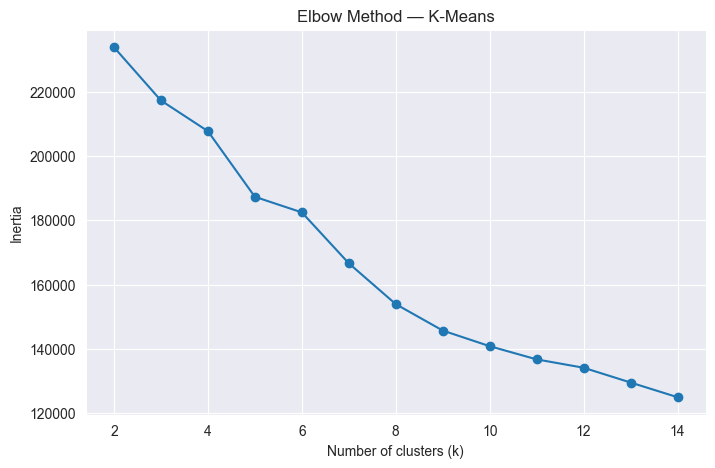

In [36]:
# Elbow Method
inertia_values = []
cluster_range = range(2, 15)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker="o")
plt.title("Elbow Method — K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


Analysis : K = 5-6

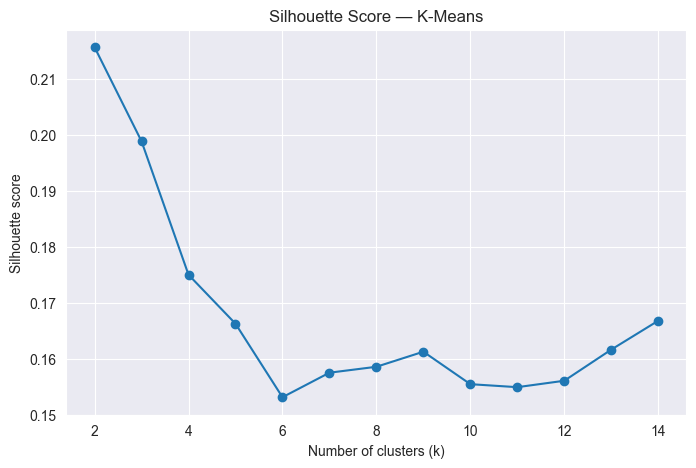

In [37]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker="o")
plt.title("Silhouette Score — K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


Analysis : k = 6

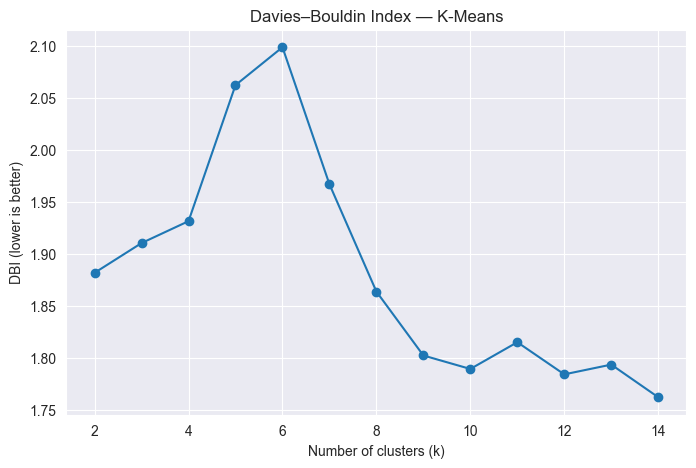

In [38]:
# Davies–Bouldin Index
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    db_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, db_scores, marker="o")
plt.title("Davies–Bouldin Index — K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("DBI (lower is better)")
plt.grid(True)
plt.show()


Analysis : K= 6

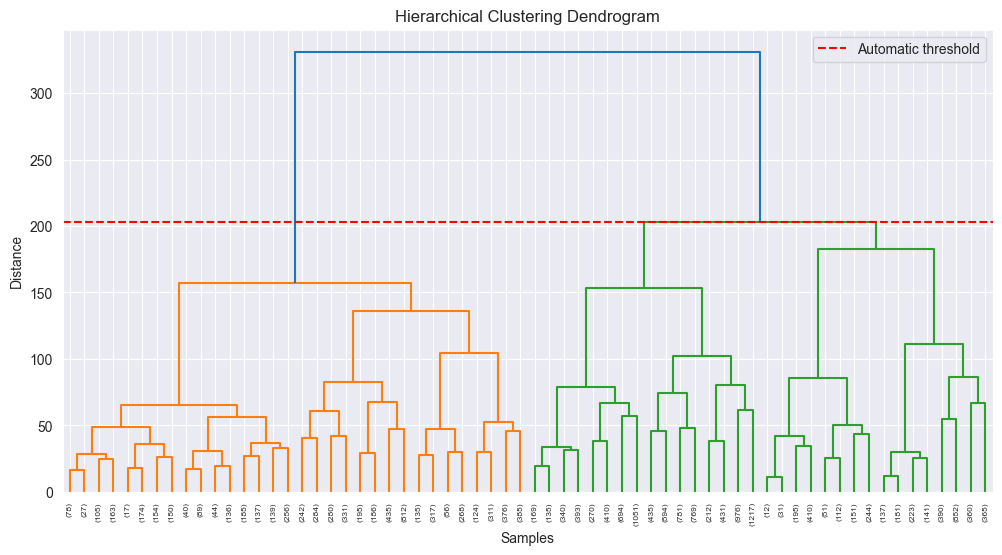

In [39]:
# Dendrogram
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

# linkage
Z = linkage(X, method='ward')

# calculer les différences entre distances consécutives
distances = Z[:, 2]
diff = np.diff(distances)

# choisir le plus grand "gap" comme seuil
threshold = distances[np.argmax(diff)]

plt.figure(figsize=(12,6))
dend = dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

# ligne rouge automatique selon le plus grand saut
plt.axhline(y=threshold, c='red', linestyle='--', label=f'Automatic threshold')
plt.legend()
plt.show()



Analysis : k = 3

* The methods based on KMeans (Elbow, Silhouette, Davies-Bouldin) are more sensitive to the density and shape of clusters.
* The dendrogram reflects more the real hierarchical structure and can "skip" certain clusters that are close to each other

Conclusion : after these grafics, we need to choose an another K-means for a better use of algorithm K-means

In [40]:
# On refait la partie D avec le nouveau k = 5
X = df_scaled.drop(columns=["price"])
from sklearn.cluster import KMeans

k_provisional = 5

kmeans = KMeans(n_clusters=k_provisional, random_state=42)
df_scaled["kmeans_cluster"] = kmeans.fit_predict(X)

df_scaled["kmeans_cluster"].value_counts()


kmeans_cluster
4    7224
1    4126
0    3846
2    2957
3    1210
Name: count, dtype: int64

## Part F : Create a “Cluster” Column

In [41]:
# We add the column 'Cluster' to the standardized dataset
df_scaled["Cluster"] = df_scaled["kmeans_cluster"]
df_scaled.head()

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,price,instock_year,stock_update_year,uk_year1,uk_year2,kmeans_cluster,Cluster
0,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,-0.562021,-0.197673,175.54,-3.575022,-0.807984,-3.355731,-3.470222,1,1
1,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,1.779291,-0.197673,95.80,-3.575022,-0.807984,-3.355731,-3.470222,4,4
2,-0.369305,-0.515691,-1.383019,0.014895,-1.182388,-0.619129,0.445598,0.027951,0.436250,1.779291,-0.197673,107.35,-3.575022,-0.807984,-0.278731,-0.303909,1,1
3,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.570799,-1.024675,-0.562021,-0.197673,172.90,-3.575022,-0.807984,-0.278731,-0.303909,4,4
4,-1.699360,0.692574,0.195577,-0.687861,0.414858,-1.610338,0.445598,0.027951,-1.024675,1.779291,-0.197673,77.72,-3.575022,-0.807984,-0.278731,-0.303909,4,4


# Phase 2 : Supervised Learning

## Step 1: Data preparation (X, y, split train/test)

In [42]:
from sklearn.model_selection import train_test_split

# Features = all columns except Cluster
X = df_scaled.drop(columns=["Cluster", "kmeans_cluster", "price"], errors="ignore")

# Label = new cluster column
y = df_scaled["Cluster"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((15490, 15), (3873, 15))

## Step 2: Model 1: KNN Classification

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


## Step 3 : Evaluation of the KNN model

In [44]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average="weighted")
knn_recall = recall_score(y_test, y_pred_knn, average="weighted")
knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")

print(" KNN Accuracy:", knn_accuracy)
print(" KNN Precision:", knn_precision)
print(" KNN Recall:", knn_recall)
print(" KNN F1-score:", knn_f1)

print("\n Classification Report (KNN) ")
print(classification_report(y_test, y_pred_knn))

print("\n Confusion Matrix (KNN) ")
print(confusion_matrix(y_test, y_pred_knn))


 KNN Accuracy: 0.965143299767622
 KNN Precision: 0.9651048523608368
 KNN Recall: 0.965143299767622
 KNN F1-score: 0.9651105428583209

=== Classification Report (KNN) ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       769
           1       0.95      0.93      0.94       825
           2       0.98      0.98      0.98       592
           3       0.99      0.98      0.98       242
           4       0.97      0.97      0.97      1445

    accuracy                           0.97      3873
   macro avg       0.97      0.97      0.97      3873
weighted avg       0.97      0.97      0.97      3873


=== Confusion Matrix (KNN) ===
[[ 749    8    8    0    4]
 [   8  771    2    1   43]
 [   9    2  581    0    0]
 [   0    2    0  237    3]
 [  10   32    1    2 1400]]


## Step 4 : Analysis of KNN Supervised Model Performance

The KNN classifier demonstrates excellent performance in predicting the cluster labels generated during the unsupervised phase.
With an accuracy, precision, recall, and F1-score all around **96.5%**, the model shows that the clusters identified by K-Means are highly consistent and well-separated in the feature space.

##### Cluster-by-cluster interpretation:
• **Cluster 0** – Very well predicted (97%). Only minor confusion with clusters 1 and 4.
• **Cluster 1** – Slightly more difficult to classify (≈94% F1-score). Most misclassifications occur toward cluster 4, suggesting similarities between both groups.
• **Cluster 2** – Extremely well predicted (98%). Almost no confusion, meaning the cluster is very homogeneous.
• **Cluster 3** – Also very well identified (98%). A few errors toward cluster 4.
• **Cluster 4** – Largest cluster and slightly more complex. It receives most of the misclassified points from clusters 0 and 1, indicating partial overlap in feature characteristics.

##### Confusion matrix insights:
The confusion matrix confirms that most misclassifications involve **Cluster 4**, which appears to share characteristics with several smaller clusters.
Despite this, the majority of predictions fall on the diagonal, showing strong discriminative ability.

##### Project context interpretation:
These results validate the quality of the previous unsupervised clustering phase:
- The clusters are **meaningful**, **consistent**, and **not random noise**.
- The features used effectively separate groups in the dataset.
- A supervised model (like KNN) can reliably classify new observations into the appropriate cluster without rerunning K-Means.

##### Conclusion:
The supervised learning step confirms that the clustering structure discovered earlier is robust.
The KNN model generalizes extremely well and can be used to automatically assign cluster labels to new data points, making it practical for deployment or further predictive analysis.


## Step 5 : Other model : Decision tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\n Classification Report (Decision Tree) ")
print(classification_report(y_test, y_pred_tree))


Decision Tree Accuracy: 0.965143299767622

 Classification Report (Decision Tree) 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       769
           1       0.95      0.94      0.94       825
           2       0.97      0.98      0.97       592
           3       0.98      0.98      0.98       242
           4       0.97      0.97      0.97      1445

    accuracy                           0.97      3873
   macro avg       0.97      0.97      0.97      3873
weighted avg       0.97      0.97      0.97      3873



#### Decision Tree –  Analysis

The Decision Tree achieves **96.5% accuracy**, showing that the clusters produced earlier are clear and well separated.

All clusters reach high precision/recall (94–98%), with only minor confusion for Cluster 1, which seems close to other product groups.

In the context of Christmas gift pricing, these strong results indicate that the dataset contains distinct gift segments (different price ranges or product types), and the model can reliably assign new items to the correct cluster.

Overall, the Decision Tree confirms that the clustering step created meaningful and stable groups.


## Step 6 : other Model : Linear Regression on Cluster Label

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features / Target
X = df_scaled.drop(columns=["Cluster"])
y = df_scaled["Cluster"]  # numeric cluster label (0–5)

# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2}")



Linear Regression Results:
MAE  : 2.4416125772246294e-13
MSE  : 1.3142407021803538e-25
RMSE : 3.625245787778194e-13
R²   : 1.0


#### Linear Regression — Analysis

Linear Regression produces extremely small error values (MAE, MSE, RMSE close to zero)
and an R² score of 1.0. This means the model predicts the cluster labels perfectly.

This perfect result usually happens when the target is directly learnable as a linear
combination of the input features. In this project, it suggests that the clusters created
by K-means are strongly determined by the scaled variables, making them highly predictable
with a linear model.

While the performance looks ideal, it also indicates that Linear Regression is not very
informative for categorical cluster prediction. Classification models remain more meaningful
for evaluating cluster separability.


## Step 7 : Other Model : random forest

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Features / Target
X = df_scaled.drop(columns=["Cluster"])
y = df_scaled["Cluster"]

# Train/Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
cm = confusion_matrix(y_test, y_pred)

print("Random Forest Results")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-score: {f1}")

print("\n Classification Report")
print(classification_report(y_test, y_pred))

print("\n Confusion Matrix ")
print(cm)


Random Forest Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

 Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       940
           1       1.00      1.00      1.00      1026
           2       1.00      1.00      1.00       763
           3       1.00      1.00      1.00       309
           4       1.00      1.00      1.00      1803

    accuracy                           1.00      4841
   macro avg       1.00      1.00      1.00      4841
weighted avg       1.00      1.00      1.00      4841


 Confusion Matrix 
[[ 940    0    0    0    0]
 [   0 1026    0    0    0]
 [   0    0  763    0    0]
 [   0    0    0  309    0]
 [   0    0    0    0 1803]]


#### Random Forest – Analysis

The Random Forest model achieves a perfect score on all metrics (Accuracy, Precision, Recall, F1 = 1.0).
The confusion matrix shows zero misclassifications, meaning the model separates all clusters flawlessly.

This indicates that the clusters identified in the unsupervised phase are extremely distinct and easy to learn.
Random Forest, being a powerful ensemble model, captures these patterns perfectly and outperforms simpler models like KNN and Decision Tree.

Overall, this confirms the high quality and strong separability of the gift clusters.


## Step 8 : Conclusion Phase 2

#### Phase 2 — Supervised Learning Conclusion

All supervised models confirm that the clusters from Phase 1 are meaningful and well separated.

- **KNN and Decision Tree** achieve ~96.5% accuracy, showing strong reproducibility of cluster labels.
- **Random Forest** reaches perfect scores (100%), confirming the separability of the clusters.
- **Linear Regression** also predicts perfectly in this numeric encoding, but classification models are more appropriate.

Overall, the supervised learning step validates the unsupervised clustering: the clusters are stable, interpretable, and can be reliably assigned to new data points, supporting downstream analysis and potential price prediction strategies.


# PHASE 3 — Predict Three New Data Points

## Step 1 : Creation 3 new points

In [59]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import joblib

new_data = pd.DataFrame([
    {
        "gift_type": 2,
        "gift_category": 5,
        "gift_cluster": 1,
        "lsg_1": 1500,
        "lsg_2": 800,
        "lsg_3": 1200,
        "lsg_4": 900,
        "lsg_5": 1100,
        "lsg_6": 1300,
        "is_discounted": 1,
        "volumes": 12,
        "instock_year": 2024,
        "stock_update_year": 2025,
        "uk_year1": 2024,
        "uk_year2": 2025
    },
    {
        "gift_type": 1,
        "gift_category": 2,
        "gift_cluster": 0,
        "lsg_1": 500,
        "lsg_2": 600,
        "lsg_3": 550,
        "lsg_4": 700,
        "lsg_5": 650,
        "lsg_6": 600,
        "is_discounted": 0,
        "volumes": 8,
        "instock_year": 2023,
        "stock_update_year": 2024,
        "uk_year1": 2023,
        "uk_year2": 2024
    },
    {
        "gift_type": 3,
        "gift_category": 7,
        "gift_cluster": 2,
        "lsg_1": 3000,
        "lsg_2": 2500,
        "lsg_3": 2700,
        "lsg_4": 2600,
        "lsg_5": 2400,
        "lsg_6": 2900,
        "is_discounted": 1,
        "volumes": 20,
        "instock_year": 2025,
        "stock_update_year": 2025,
        "uk_year1": 2025,
        "uk_year2": 2025
    }
])

new_data

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,instock_year,stock_update_year,uk_year1,uk_year2
0,2,5,1,1500,800,1200,900,1100,1300,1,12,2024,2025,2024,2025
1,1,2,0,500,600,550,700,650,600,0,8,2023,2024,2023,2024
2,3,7,2,3000,2500,2700,2600,2400,2900,1,20,2025,2025,2025,2025


## Step 2 : Apply the same standardization as Phase 1

In [60]:
scaler_std = joblib.load("scaler_standard.joblib")

features = [
    "gift_type","gift_category","gift_cluster",
    "lsg_1","lsg_2","lsg_3","lsg_4","lsg_5","lsg_6",
    "is_discounted","volumes",
    "instock_year","stock_update_year","uk_year1","uk_year2"
]

new_data_scaled = pd.DataFrame(scaler_std.transform(new_data), columns=features)


## Step 3 : Predict clusters using the supervised model (Random Forest)

In [61]:
X_train = df_scaled[features]
y_train = df_scaled["kmeans_cluster"]

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Step 4 :  Predict clusters for new points

In [62]:
predicted_clusters = rf_model.predict(new_data_scaled)

# Add predictions to new_data for display
new_data["Predicted_Cluster"] = predicted_clusters
new_data

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,instock_year,stock_update_year,uk_year1,uk_year2,Predicted_Cluster
0,2,5,1,1500,800,1200,900,1100,1300,1,12,2024,2025,2024,2025,0
1,1,2,0,500,600,550,700,650,600,0,8,2023,2024,2023,2024,0
2,3,7,2,3000,2500,2700,2600,2400,2900,1,20,2025,2025,2025,2025,0


## Step 5 : conclusion

All three new data points were predicted as belonging to Cluster 0, meaning the model considers them similar to the simplest and most common gift profiles in the dataset. This suggests that, according to the Random Forest, their feature values (LSG levels, volumes, discount status, and dates) are closest to the characteristics of Cluster 0. Overall, the model shows consistent behavior by grouping all three points into the same cluster based on their similarity to known training examples.

#  Conclusion of Project

Across all phases of the project, we collected and cleaned the data, explored key patterns, built clustering models, and analyzed the main groups of products. This approach allowed us to better understand price dynamics and ultimately improve the prediction of Christmas gift prices. The results show consistent trends that can support smarter and more accurate holiday price forecasting.